<a href="https://colab.research.google.com/github/nfcr7/TP1/blob/main/TP3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [70]:
import cv2
import numpy as np
from scipy import datasets
i = datasets.ascent()

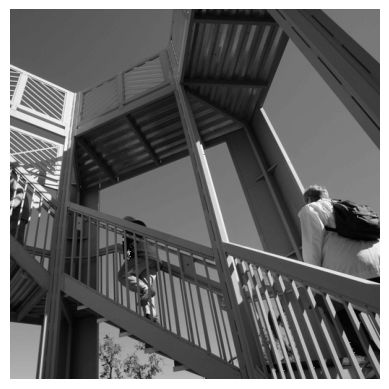

In [71]:
import matplotlib.pyplot as plt
plt.grid(False)

plt.gray()
plt.axis('off')
plt.imshow(i)
plt.show()

In [72]:
i_transformed = np.copy(i)
size_x = i_transformed.shape[0]
size_y = i_transformed.shape[1]

In [73]:
filtre = [ [0, 1, 0], [1, -4, 1], [0, 1, 0]]
# Encore quelques filtres à essayer pour le plaisir!
#filtre = [ [-1, -2, -1], [0, 0, 0], [1, 2, 1]]
#filtre = [ [-1, 0, 1], [-2, 0, 2], [-1, 0, 1]]

In [74]:
i_float_for_convolution = i.astype(np.float64)

poids = 1.5
for x in range(1,size_x-1):
   for y in range(1,size_y-1):
    out = 0.0

    out = out + i_float_for_convolution[x-1,y-1]*filtre[0][0]
    out = out + i_float_for_convolution[x,y-1]*filtre[0][1]
    out = out + i_float_for_convolution[x+1,y-1]*filtre[0][2]
    out = out + i_float_for_convolution[x-1,y]*filtre[1][0]
    out = out + i_float_for_convolution[x,y]*filtre[1][1]
    out = out + i_float_for_convolution[x+1,y]*filtre[1][2]
    out = out + i_float_for_convolution[x-1,y+1]*filtre[2][0]
    out = out + i_float_for_convolution[x,y+1]*filtre[2][1]
    out = out + i_float_for_convolution[x+1,y+1]*filtre[2][2]

    out = out * poids
    if(out<0):
     out=0
    if(out>255):
     out=255
    i_transformed[x, y] = out

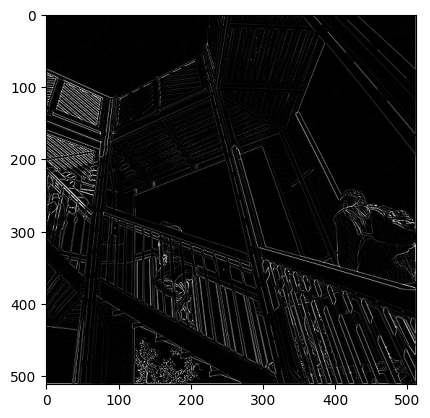

In [75]:

plt.gray()
plt.grid(False)
plt.imshow(i_transformed)
plt.show()

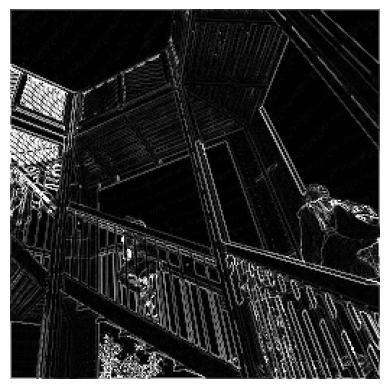

In [77]:
new_x = int(size_x/2)
new_y = int(size_y/2)
newImage = np.zeros((new_x, new_y))

for x in range(0, size_x, 2):
    for y in range(0, size_y, 2):
        pixels = []
        pixels.append(i_transformed[x, y])
        pixels.append(i_transformed[x+1, y])
        pixels.append(i_transformed[x, y+1])
        pixels.append(i_transformed[x+1, y+1])
        pixels.sort(reverse=True)
        newImage[int(x/2), int(y/2)] = pixels[0]


plt.gray()
plt.grid(False)
plt.imshow(newImage)
plt.axis('off')
plt.show()